This is the analysis script for rustc-perf benchmarks.

In [1]:
import sqlite3
import pandas as pd

OWNSEM_DB = '../artifacts/rustc-perf/results_ownsem.db'
NO_LOAD_ONLY_DB = '../artifacts/rustc-perf/results_no_load_only.db'

def fetch_metric_data(db_path, metrics, aid_list):
  data = []
  for metric in metrics:
    query = """
    SELECT
      s.benchmark AS benchmark,
      a.name AS artifact,
      s.metric AS metric,
      r.value
    FROM runtime_pstat r
    JOIN runtime_pstat_series s ON r.series = s.id
    JOIN artifact a ON r.aid = a.id
    WHERE r.aid IN ({aids}) AND s.metric = ?
    ORDER BY s.benchmark, a.name;
    """.format(aids=','.join(['?']*len(aid_list)))
    params = aid_list + [metric]
    with sqlite3.connect(db_path) as conn:
      cursor = conn.cursor()
      cursor.execute(query, params)
      data.extend(cursor.fetchall())
  return data

def fetch_all_metrics_as_dataframe(db_path, metrics, aid_list=[1, 2]):
  data = fetch_metric_data(db_path, metrics, aid_list)
  df = pd.DataFrame(data, columns=['benchmark', 'id', 'metric', 'value'])
  df = df.pivot_table(index=['benchmark', 'id'], columns='metric', values='value', aggfunc='mean').reset_index()
  df = df[['benchmark', 'id'] + metrics]
  return df

# Example usage:
# results = fetch_metric_values('your_database.db')
# for row in results:
#     print(row)

In [2]:
def list_all_metrics(db_path):
  query = "SELECT DISTINCT metric FROM runtime_pstat_series ORDER BY metric;"
  with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute(query)
    metrics = [row[0] for row in cursor.fetchall()]
  return metrics

def list_benchmarks_ids_and_counts(db_path):
  query = """
    SELECT s.benchmark, a.name AS id, COUNT(r.value) AS num_samples
    FROM runtime_pstat r
    JOIN runtime_pstat_series s ON r.series = s.id
    JOIN artifact a ON r.aid = a.id
    WHERE s.metric = 'cache-references'
    GROUP BY s.benchmark, a.name
    ORDER BY s.benchmark, a.name;
  """
  with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute(query)
    results = cursor.fetchall()
  # Returns a list of tuples: (benchmark, id, num_samples)
  return results

# Example usage:
# metrics = list_all_metrics('../artifacts/rustc-perf/results_ownsem.db')
# print(metrics)

In [3]:
results = list_benchmarks_ids_and_counts(OWNSEM_DB)
for row in results:
  print(row)

('brotli-compress', 'default_licm', 100)
('brotli-compress', 'ownsem_licm', 100)
('brotli-decompress', 'default_licm', 100)
('brotli-decompress', 'ownsem_licm', 100)
('bufreader_snappy', 'default_licm', 100)
('bufreader_snappy', 'ownsem_licm', 100)
('css-parse-fb', 'default_licm', 100)
('css-parse-fb', 'ownsem_licm', 100)
('fmt-debug-derive', 'default_licm', 100)
('fmt-debug-derive', 'ownsem_licm', 100)
('fmt-write-str', 'default_licm', 100)
('fmt-write-str', 'ownsem_licm', 100)
('hashmap_find_1m', 'default_licm', 100)
('hashmap_find_1m', 'ownsem_licm', 100)
('hashmap_find_misses_1m', 'default_licm', 100)
('hashmap_find_misses_1m', 'ownsem_licm', 100)
('hashmap_insert_1m', 'default_licm', 100)
('hashmap_insert_1m', 'ownsem_licm', 100)
('hashmap_iterate_1m', 'default_licm', 100)
('hashmap_iterate_1m', 'ownsem_licm', 100)
('hashmap_remove_1m', 'default_licm', 100)
('hashmap_remove_1m', 'ownsem_licm', 100)
('nbody_5k', 'default_licm', 100)
('nbody_5k', 'ownsem_licm', 100)
('nom-json', 'de

Calculate perf as new_metric/old_metric

In [4]:
# Replace zeros with epsilon for each (metric, id) pair
def compute_perf_improvement(results, metrics, new_key, old_key, epsilon=1e-12):
  # Pivot the results DataFrame
  pivoted = results.pivot(index='benchmark', columns='id', values=metrics)
  # Replace zeros with epsilon for each (metric, id) pair
  for metric in metrics:
    for id_ in [old_key, new_key]:
      pivoted[(metric, id_)] = pivoted[(metric, id_)].replace(0, epsilon)
  # Calculate new_key / old_key for each metric
  perf_improvement = pd.DataFrame(
    {
      metric: pivoted[(metric, new_key)] / pivoted[(metric, old_key)]
      for metric in metrics
    }
  )
  perf_improvement.reset_index(inplace=True)
  return perf_improvement


In [5]:
import numpy as np

metrics_ownsem = list_all_metrics(OWNSEM_DB)
results_ownsem = fetch_all_metrics_as_dataframe(OWNSEM_DB, metrics_ownsem)
perf_improvement_ownsem = compute_perf_improvement(results_ownsem, metrics_ownsem, new_key='ownsem_licm', old_key='default_licm')

geo_means_ownsem = perf_improvement_ownsem[metrics_ownsem].apply(lambda x: np.exp(np.nanmean(np.log(x))), axis=0)
print(geo_means_ownsem)

branch-misses       1.008595
cache-misses        0.929463
cache-references    1.027050
cycles:u            0.999357
instructions:u      0.998873
wall-time           0.999253
dtype: float64


In [6]:
metrics_no_load_only = list_all_metrics(NO_LOAD_ONLY_DB)
results_no_load_only = fetch_all_metrics_as_dataframe(NO_LOAD_ONLY_DB, metrics_no_load_only)
perf_improvement_no_load_only = compute_perf_improvement(results_no_load_only, metrics_no_load_only, new_key='default_licm', old_key='no_load_only_licm')

geo_means_no_load_only = perf_improvement_no_load_only[metrics_no_load_only].apply(lambda x: np.exp(np.nanmean(np.log(x))), axis=0)
print(geo_means_no_load_only)

branch-misses       0.946335
cache-misses        0.947704
cache-references    1.036593
cycles:u            0.993480
instructions:u      0.999957
wall-time           0.993858
dtype: float64


In [7]:
from scipy.stats import ttest_ind
import numpy as np

def get_p_val(db_path, metric, new_key, old_key, n_bootstrap=10000):
  # Fetch data for the metric and both keys
  data = fetch_metric_data(db_path, [metric], aid_list=[1, 2])
  df = pd.DataFrame(data, columns=['benchmark', 'id', 'metric', 'value'])

  # If the dataframe is empty, return empty dict
  if df.empty:
    print("No data found for the given metric and keys.")
    return {}

  # Group by benchmark only
  p_val_dict = {}
  grouped = df.groupby('benchmark')
  print(f"Calculating p-values for {len(grouped)} benchmarks...")
  for benchmark, group in grouped:
    old_vals = group[group['id'] == old_key]['value'].values
    new_vals = group[group['id'] == new_key]['value'].values
    # Check for non-zero and equal-length distributions
    if len(old_vals) == 0 or len(new_vals) == 0:
      p_val_dict[benchmark] = np.nan
      continue
    if len(old_vals) != len(new_vals):
      p_val_dict[benchmark] = np.nan
      continue
    # Calculate observed t-score
    t_obs, _ = ttest_ind(new_vals, old_vals, equal_var=False)
    # Bootstrap
    t_bootstrap = []
    for _ in range(n_bootstrap):
      old_sample = np.random.choice(old_vals, size=len(old_vals), replace=True)
      new_sample = np.random.choice(new_vals, size=len(new_vals), replace=True)
      t_bs, _ = ttest_ind(new_sample, old_sample, equal_var=False)
      t_bootstrap.append(t_bs)
    t_bootstrap = np.array(t_bootstrap)
    p_val = np.mean(np.abs(t_bootstrap) >= np.abs(t_obs))
    p_val_dict[benchmark] = p_val

  return p_val_dict


In [8]:
p_val_dict = get_p_val(OWNSEM_DB, 'cache-references', 'ownsem_licm', 'default_licm', n_bootstrap=100)
for key, val in p_val_dict.items():
  print(f"{key}: {val}")

Calculating p-values for 19 benchmarks...


brotli-compress: 0.53
brotli-decompress: 0.59
bufreader_snappy: 0.56
css-parse-fb: 0.61
fmt-debug-derive: 0.58
fmt-write-str: 0.5
hashmap_find_1m: 0.6
hashmap_find_misses_1m: 0.48
hashmap_insert_1m: 0.51
hashmap_iterate_1m: 0.38
hashmap_remove_1m: 0.55
nbody_5k: 0.53
nom-json: 0.54
pinky-nes15: 0.49
raytracer: 0.44
regex-capture-1: 0.52
regex-search-1: 0.56
svg-parse-1: 0.47
svg-render-1: 0.54


In [22]:
import numpy as np
from scipy.stats import ttest_ind
from typing import Dict, Any, Optional
import logging

def _welch_t(x: np.ndarray, y: np.ndarray, log_level=logging.INFO) -> float:
    logging.basicConfig(level=log_level)
    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        raise ValueError("Need at least 2 samples per group for Welch t.")
    v1 = np.var(x, ddof=1)
    v2 = np.var(y, ddof=1)
    if np.isclose(v1, 0) and np.isclose(v2, 0):
        return 0.0 if np.isclose(np.mean(x), np.mean(y)) else np.inf
    denom = np.sqrt(v1 / n1 + v2 / n2)
    if np.isclose(denom, 0):
        return 0.0
    return (np.mean(x) - np.mean(y)) / denom

def _welch_t_criterion_var(x: np.ndarray, y: np.ndarray, log_level=logging.INFO) -> float:
    logging.basicConfig(level=log_level)
    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        raise ValueError("Need at least 2 samples per group for Welch t.")

    mean_x = np.mean(x)
    mean_y = np.mean(y)
    logging.debug(f"mean_x: {mean_x} mean_y: {mean_y}")
    v1 = np.sum((x - mean_x) ** 2) / (n1 - 1)
    v2 = np.sum((y - mean_y) ** 2) / (n2 - 1)
    logging.debug(f"v1: {v1} v2: {v2}")
    if np.isclose(v1, 0) and np.isclose(v2, 0):
        return 0.0 if np.isclose(np.mean(x), np.mean(y)) else np.inf

    denom = np.sqrt(v1 / n1 + v2 / n2)
    logging.debug(f"denom: {denom}")
    if np.isclose(denom, 0):
        return 0.0

    return (mean_x - mean_y) / denom

def get_bootstrap_median_improve_boxplot_stats(
    rng,
    a: np.ndarray,
    b: np.ndarray,
    n_bootstrap: int = 10000,
    log_level=logging.INFO
):
    logging.basicConfig(level=log_level)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        raise ValueError("Each group must have at least 2 samples.")
    ratios = []
    for i in range(n_bootstrap):
        a_resample = rng.choice(a, size=a.size, replace=True)
        b_resample = rng.choice(b, size=b.size, replace=True)
        median_a = np.median(a_resample)
        median_b = np.median(b_resample)
        if np.isclose(median_a, 0.0):
            ratios.append(np.nan)
        else:
            ratios.append(median_b / median_a)
    ratios = np.array(ratios)
    ratios = ratios[~np.isnan(ratios)]
    if ratios.size == 0:
        return {
            "min": np.nan,
            "q1": np.nan,
            "median": np.nan,
            "q3": np.nan,
            "max": np.nan,
            "iqr": np.nan
        }
    q1 = np.percentile(ratios, 25)
    median = np.percentile(ratios, 50)
    q3 = np.percentile(ratios, 75)
    iqr = q3 - q1
    lower_whisker = np.min(ratios[ratios >= (q1 - 1.5 * iqr)])
    upper_whisker = np.max(ratios[ratios <= (q3 + 1.5 * iqr)])
    return {
        "min": float(lower_whisker),
        "q1": float(q1),
        "median": float(median),
        "q3": float(q3),
        "max": float(upper_whisker),
        "iqr": float(iqr)
    }

def criterion_compare(
    old_vals: np.ndarray,
    new_vals: np.ndarray,
    *,
    n_bootstrap: int = 10_000,
    alpha: float = 0.05,
    noise_threshold_pct: float = 1,
    smaller_is_better: bool = True,
    random_state: Optional[int] = None,
    use_monte_carlo: bool = False,
    log_level: int = logging.INFO
) -> Dict[str, Any]:
    logger = logging.getLogger(__name__)
    logger.setLevel(log_level)
    old_vals = np.asarray(old_vals, dtype=float)
    new_vals = np.asarray(new_vals, dtype=float)
    if len(old_vals) < 2 or len(new_vals) < 2:
        raise ValueError("Each group must have at least 2 samples.")
    if np.allclose(np.var(old_vals, ddof=1), 0) and np.allclose(np.var(new_vals, ddof=1), 0):
        return {
            "t_obs": 0.0, "p_value": 1.0, "significant": False,
            "abs_change_mean": 0.0, "abs_change_median": 0.0,
            "rel_change_mean_pct": 0.0, "rel_change_median_pct": 0.0,
            "rel_change_mean_ci": (0.0, 0.0),
            "rel_change_median_ci": (0.0, 0.0),
            "classification": "no-change (identical samples)"
        }

    rng = np.random.default_rng(random_state)
    t_obs = _welch_t(new_vals, old_vals, log_level=log_level)
    n_old, n_new = len(old_vals), len(new_vals)
    t_boot = np.empty(n_bootstrap, dtype=float)
    abs_mean_diff = np.empty(n_bootstrap, dtype=float)
    abs_median_diff = np.empty(n_bootstrap, dtype=float)
    rel_mean_pct = np.empty(n_bootstrap, dtype=float)
    rel_median_pct = np.empty(n_bootstrap, dtype=float)

    logger.debug(f"Old values distribution: {old_vals}")
    logger.debug(f"New values distribution: {new_vals}")

    for b in range(n_bootstrap):
        combined = np.concatenate([old_vals, new_vals])
        resampled = rng.choice(combined, size=combined.size, replace=True)
        old_bs = resampled[:n_old]
        new_bs = resampled[n_old:]
        tb = _welch_t(new_bs, old_bs, log_level=log_level)
        t_boot[b] = tb
    if use_monte_carlo:
        extreme = np.sum(np.abs(t_boot) >= abs(t_obs))
        p_val = (extreme + 1.0) / (n_bootstrap + 1.0)
        significant = p_val < alpha
    else:
        a = t_boot < t_obs
        hits = np.count_nonzero(a)
        logger.debug(f"t_boot: {t_boot}")
        logger.debug(f"t_obs: {t_obs}")
        logger.debug(f"a: {a}")
        logger.debug(f"hits: {hits}")
        tails = 2
        p_val = (min(hits, n_bootstrap - hits) / n_bootstrap) * tails
        significant = p_val < alpha
    # mn_old, mn_new = old_bs.mean(), new_bs.mean()
    # md_old, md_new = np.median(old_bs), np.median(new_bs)
    # abs_mean_diff[b] = mn_new - mn_old
    # abs_median_diff[b] = md_new - md_old
    # rel_mean_pct[b] = (mn_new / mn_old - 1.0) * 100.0 if not np.isclose(mn_old, 0.0) else np.nan
    # rel_median_pct[b] = (md_new / md_old - 1.0) * 100.0 if not np.isclose(md_old, 0.0) else np.nan
    # mean_old, mean_new = old_vals.mean(), new_vals.mean()
    # med_old, med_new = np.median(old_vals), np.median(new_vals)
    # obs_abs_mean = mean_new - mean_old
    # obs_abs_median = med_new - med_old
    # obs_rel_mean_pct = (mean_new / mean_old - 1.0) * 100.0 if not np.isclose(mean_old, 0.0) else np.nan
    # obs_rel_median_pct = (med_new / med_old - 1.0) * 100.0 if not np.isclose(med_old, 0.0) else np.nan
    # def pct_ci(arr, lo=2.5, hi=97.5):
    #     arr = arr[~np.isnan(arr)]
    #     if arr.size == 0:
    #         return (np.nan, np.nan)
    #     return (float(np.percentile(arr, lo)), float(np.percentile(arr, hi)))

    # rel_mean_ci = pct_ci(rel_mean_pct)
    # rel_median_ci = pct_ci(rel_median_pct)
    result = get_bootstrap_median_improve_boxplot_stats(rng, old_vals, new_vals, n_bootstrap=n_bootstrap, log_level=log_level)
    ratio = result['median'] if 'median' in result else np.nan
    within_noise = abs(ratio - 1) * 100 <= noise_threshold_pct

    if not significant:
        classification = "no-significant-change"
    elif within_noise:
        classification = f"ignored (within ±{noise_threshold_pct:.3g}% noise)"
    else:
        if np.isnan(ratio):
            classification = "change (direction undefined)"
        else:
            improved = (ratio < 1) if smaller_is_better else (ratio > 1)
            classification = "optimization" if improved else "regression"

    return {
        "t_obs": float(t_obs),
        "p_value": float(p_val),
        "alpha": float(alpha),
        "significant": bool(significant),
        "stat": result,
        # "abs_change_mean": float(obs_abs_mean),
        # "abs_change_median": float(obs_abs_median),
        # "rel_change_mean_pct": float(obs_rel_mean_pct) if not np.isnan(obs_rel_mean_pct) else np.nan,
        # "rel_change_median_pct": float(obs_rel_median_pct) if not np.isnan(obs_rel_median_pct) else np.nan,
        # "rel_change_mean_ci": rel_mean_ci,
        # "rel_change_median_ci": rel_median_ci,
        "noise_threshold_pct": float(noise_threshold_pct),
        "classification": classification,
        "n_bootstrap": int(n_bootstrap),
    }

def compute_crit_p_val(
    db_path, metric, new_key, old_key,
    n_bootstrap=10000, alpha=0.05, noise_threshold_pct=1,
    smaller_is_better=True, random_state=None, log_level=logging.INFO
):
    logging.basicConfig(level=log_level)
    data = fetch_metric_data(db_path, [metric], aid_list=[1, 2])
    df = pd.DataFrame(data, columns=['benchmark', 'id', 'metric', 'value'])

    if df.empty:
        logging.debug("No data found for the given metric and keys.")
        return {}

    results = {}
    grouped = df.groupby('benchmark')
    logging.info(f"Calculating Criterion-style results for {len(grouped)} benchmarks...")
    for benchmark, group in grouped:
        old_vals = group[group['id'] == old_key]['value'].values
        new_vals = group[group['id'] == new_key]['value'].values
        if len(old_vals) == 0 or len(new_vals) == 0:
            results[benchmark] = None
            continue
        if logging.getLogger().isEnabledFor(logging.INFO):
            logging.info(f"Processing benchmark: {benchmark} with {len(old_vals)} old samples and {len(new_vals)} new samples")
        result = criterion_compare(
            old_vals, new_vals,
            n_bootstrap=n_bootstrap,
            alpha=alpha,
            noise_threshold_pct=noise_threshold_pct,
            smaller_is_better=smaller_is_better,
            random_state=random_state,
            use_monte_carlo=False,
            log_level=log_level
        )
        results[benchmark] = result

    return results


In [10]:
def test_criterion_compare_basic():
  # Two distributions with clear difference
  old_vals = np.array([1, 2, 3, 4, 5])
  new_vals = np.array([2, 3, 4, 5, 6])
  result = criterion_compare(old_vals, new_vals, n_bootstrap=1000, alpha=0.05, noise_threshold_pct=0.1, 
                             smaller_is_better=False, random_state=42, use_monte_carlo=True, log_level=logging.DEBUG)
  print(result)
  # Check expected mean/median changes
  assert np.isclose(result['abs_change_mean'], 1.0)
  assert np.isclose(result['abs_change_median'], 1.0)
  # Relative change mean percent should be ~33.33%
  assert np.isclose(result['rel_change_mean_pct'], ((4.0/3.0)-1)*100, atol=1)
  # Classification should be 'optimization' since mean increased and smaller_is_better=False
  assert result['classification'] == 'optimization'
  # p-value should be less than alpha (statistically significant)
  assert result['p_value'] < result['alpha']

test_criterion_compare_basic()

DEBUG:__main__:Old values distribution: [1. 2. 3. 4. 5.]
DEBUG:__main__:New values distribution: [2. 3. 4. 5. 6.]


{'t_obs': 1.0, 'p_value': 0.33166833166833165, 'alpha': 0.05, 'significant': False, 'stat': {'min': 0.6666666666666666, 'q1': 1.125, 'median': 1.3333333333333333, 'q3': 1.6153846153846154, 'max': 2.3333333333333335, 'iqr': 0.4903846153846154}, 'noise_threshold_pct': 0.1, 'classification': 'no-significant-change', 'n_bootstrap': 1000}


KeyError: 'abs_change_mean'

In [28]:
p_val_ownsem_dict = compute_crit_p_val(OWNSEM_DB, 'wall-time', 'ownsem_licm', 'default_licm', n_bootstrap=10000)
for key, val in p_val_dict.items():
  print(f"{key}: {val}")

INFO:root:Calculating Criterion-style results for 19 benchmarks...
INFO:root:Processing benchmark: brotli-compress with 100 old samples and 100 new samples


INFO:root:Processing benchmark: brotli-decompress with 100 old samples and 100 new samples
INFO:root:Processing benchmark: bufreader_snappy with 100 old samples and 100 new samples
INFO:root:Processing benchmark: css-parse-fb with 100 old samples and 100 new samples
INFO:root:Processing benchmark: fmt-debug-derive with 100 old samples and 100 new samples
INFO:root:Processing benchmark: fmt-write-str with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_find_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_find_misses_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_insert_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_iterate_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_remove_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: nbody_5k with 100 old samples and 100 new samples
INFO:root:Proce

brotli-compress: 0.53
brotli-decompress: 0.59
bufreader_snappy: 0.56
css-parse-fb: 0.61
fmt-debug-derive: 0.58
fmt-write-str: 0.5
hashmap_find_1m: 0.6
hashmap_find_misses_1m: 0.48
hashmap_insert_1m: 0.51
hashmap_iterate_1m: 0.38
hashmap_remove_1m: 0.55
nbody_5k: 0.53
nom-json: 0.54
pinky-nes15: 0.49
raytracer: 0.44
regex-capture-1: 0.52
regex-search-1: 0.56
svg-parse-1: 0.47
svg-render-1: 0.54


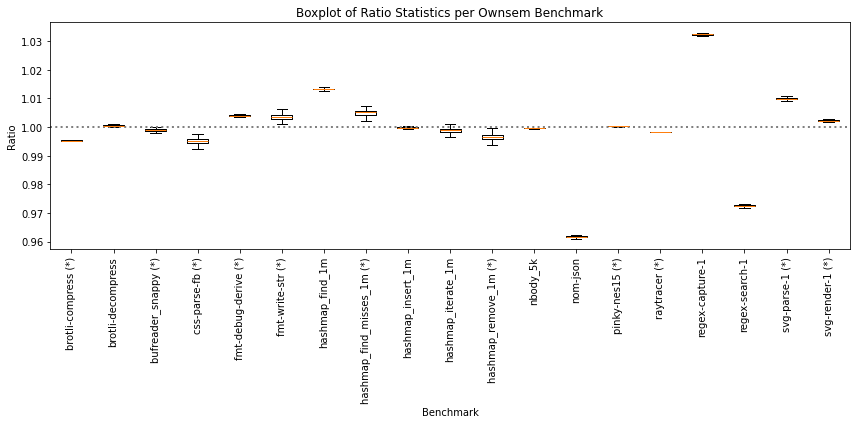

In [32]:
import matplotlib.pyplot as plt

def plot_boxplot_from_pval_dict(p_val_dict, caption):
  benchmarks = []
  boxplot_data = []
  for benchmark, entry in p_val_dict.items():
    stat = entry.get('stat', {})
    classification = entry.get('classification', '')
    # Only plot if stat is present and not None
    if stat and all(k in stat for k in ['min', 'q1', 'median', 'q3', 'max']):
      boxplot_data.append([stat['min'], stat['q1'], stat['median'], stat['q3'], stat['max']])
      # Add '*' if classification starts with 'ignored'
      if classification.startswith('ignored'):
        benchmarks.append(benchmark + ' (*)')
      else:
        benchmarks.append(benchmark)
  # Prepare boxplot values
  boxplot_vals = []
  for stats in boxplot_data:
    boxplot_vals.append({
      'whislo': stats[0],    # Bottom whisker position
      'q1': stats[1],        # First quartile (25th percentile)
      'med': stats[2],       # Median         (50th percentile)
      'q3': stats[3],        # Third quartile (75th percentile)
      'whishi': stats[4],    # Top whisker position
      'fliers': []           # Outliers
    })
  fig, ax = plt.subplots(figsize=(max(12, len(benchmarks)//2), 6))
  ax.bxp(boxplot_vals, showfliers=False, positions=range(len(benchmarks)))
  ax.set_xticks(range(len(benchmarks)))
  ax.set_xticklabels(benchmarks, rotation=90)
  ax.set_ylabel('Ratio')
  ax.set_xlabel('Benchmark')
  ax.set_title(f'Boxplot of Ratio Statistics per {caption} Benchmark')
  ax.axhline(1, color='gray', linestyle='dotted', linewidth=2)  # Draw purple dotted line at y=1
  plt.tight_layout()
  plt.show()

plot_boxplot_from_pval_dict(p_val_ownsem_dict, "Ownsem")

In [29]:
import numpy as np

# Extract all median values from 'stat' in p_val_ownsem_dict
medians = [entry['stat']['median'] for entry in p_val_ownsem_dict.values() if 'stat' in entry and 'median' in entry['stat']]

# Compute geometric mean
geo_mean_median = np.exp(np.median(np.log(medians)))
print("Geometric median of medians:", geo_mean_median)

Geometric median of medians: 0.9998384037329135


In [30]:
p_val_no_load_only_dict = compute_crit_p_val(NO_LOAD_ONLY_DB, 'wall-time', 'default_licm', 'no_load_only_licm', n_bootstrap=10000)
for key, val in p_val_dict.items():
  print(f"{key}: {val}")

INFO:root:Calculating Criterion-style results for 19 benchmarks...


INFO:root:Processing benchmark: brotli-compress with 100 old samples and 100 new samples
INFO:root:Processing benchmark: brotli-decompress with 100 old samples and 100 new samples
INFO:root:Processing benchmark: bufreader_snappy with 100 old samples and 100 new samples
INFO:root:Processing benchmark: css-parse-fb with 100 old samples and 100 new samples
INFO:root:Processing benchmark: fmt-debug-derive with 100 old samples and 100 new samples
INFO:root:Processing benchmark: fmt-write-str with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_find_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_find_misses_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_insert_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_iterate_1m with 100 old samples and 100 new samples
INFO:root:Processing benchmark: hashmap_remove_1m with 100 old samples and 100 new samples
INFO:roo

brotli-compress: 0.53
brotli-decompress: 0.59
bufreader_snappy: 0.56
css-parse-fb: 0.61
fmt-debug-derive: 0.58
fmt-write-str: 0.5
hashmap_find_1m: 0.6
hashmap_find_misses_1m: 0.48
hashmap_insert_1m: 0.51
hashmap_iterate_1m: 0.38
hashmap_remove_1m: 0.55
nbody_5k: 0.53
nom-json: 0.54
pinky-nes15: 0.49
raytracer: 0.44
regex-capture-1: 0.52
regex-search-1: 0.56
svg-parse-1: 0.47
svg-render-1: 0.54


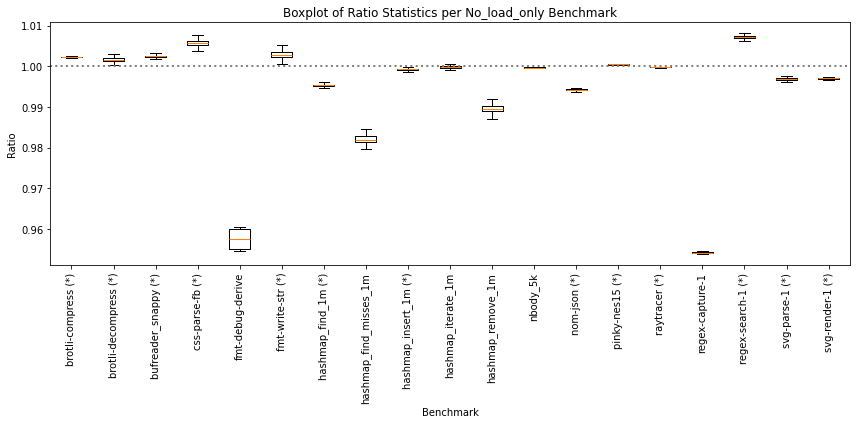

Geometric median of medians: 0.9996465345945003


In [33]:
import numpy as np

plot_boxplot_from_pval_dict(p_val_no_load_only_dict, 'No_load_only')

# Extract all median values from 'stat' in p_val_ownsem_dict
medians_no_load_only = [entry['stat']['median'] for entry in p_val_no_load_only_dict.values() if 'stat' in entry and 'median' in entry['stat']]

# Compute geometric median
geo_mean_median_no_load_only = np.exp(np.median(np.log(medians_no_load_only)))
print("Geometric median of medians:", geo_mean_median_no_load_only)

In [ ]:
import matplotlib.pyplot as plt

def plot_cache_refs(df, caption_prefix, new_key, old_key):
  """
  Plots a bar graph of the ratio of cache-references (new_key / old_key) for each benchmark.
  :param df: pandas DataFrame with columns 'benchmark', 'id', 'cache-references'
  :param new_key: str, name of the new artifact (e.g., 'ownsem_licm')
  :param old_key: str, name of the old artifact (e.g., 'default_licm')
  """
  # Group by benchmark and id, then average instructions:u
  grouped = df.groupby(['benchmark', 'id'])['instructions:u'].mean().unstack()
  # Compute ratio, avoid division by zero
  ratio = grouped[new_key] / grouped[old_key]
  # Plot bar graph
  plt.figure(figsize=(max(12, len(ratio) // 2), 6))
  ratio.plot(kind='bar')
  plt.axhline(1, color='orange', linestyle='dotted', linewidth=2)
  plt.ylabel(f'Cache References Ratio ({new_key}/{old_key})')
  plt.xlabel('{} Benchmark'.format(caption_prefix))
  plt.title('Cache References Ratio per Benchmark')
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()


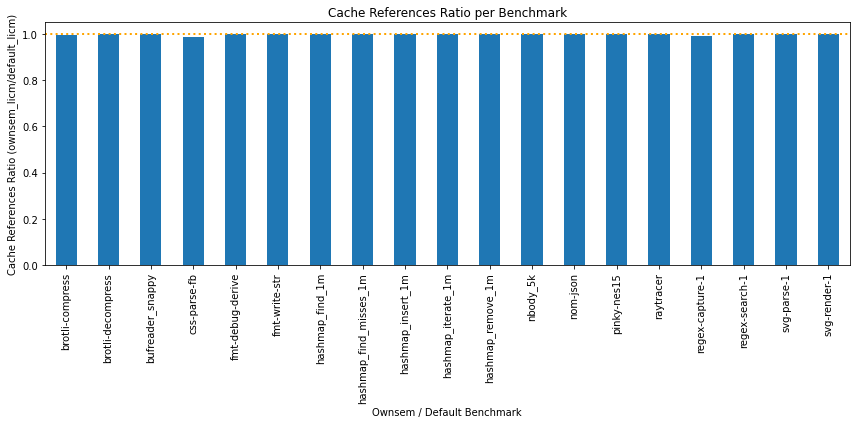

In [ ]:
df_cache_refs = pd.DataFrame(
  fetch_metric_data(OWNSEM_DB, ['instructions:u'], [1, 2]),
  columns=['benchmark', 'id', 'metric', 'instructions:u']
)
plot_cache_refs(df_cache_refs, 'Ownsem / Default', 'ownsem_licm', 'default_licm')

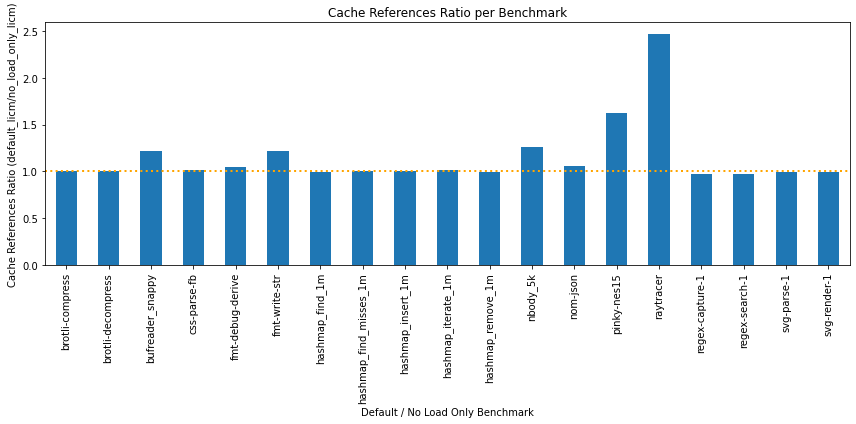

In [ ]:
df_cache_refs = pd.DataFrame(
  fetch_metric_data(NO_LOAD_ONLY_DB, ['cache-references'], [1, 2]),
  columns=['benchmark', 'id', 'metric', 'cache-references']
)
plot_cache_refs(df_cache_refs, 'Default / No Load Only', 'default_licm', 'no_load_only_licm')

In [ ]:

import numpy as np

# Input samples
A = np.array([1, 2, 3, 4, 5])
B = np.array([2, 3, 4, 5, 6])

# Parameters
n_resamples = 10000
rng = np.random.default_rng(42)

# Combine data for resampling under null
combined = np.concatenate([A, B])
nA, nB = len(A), len(B)

def welch_t_stat(x, y):
    nx, ny = len(x), len(y)
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    num = mx - my
    den = np.sqrt(vx/nx + vy/ny)
    return num / den

# Observed Welch t-statistic
obs_t = welch_t_stat(A, B)

# Bootstrap distribution of Welch t-statistic
boot_t = []
for _ in range(n_resamples):
    resampled = rng.choice(combined, size=combined.size, replace=True)
    resA = resampled[:nA]
    resB = resampled[nA:]
    boot_t.append(welch_t_stat(resA, resB))

boot_t = np.array(boot_t)

# Two-sided bootstrap p-value for Welch t-statistic
p_value_t = np.mean(np.abs(boot_t) >= np.abs(obs_t))

obs_t, p_value_t

(-1.0, 0.3358)